# Filter Audit Viz

Loads `output/eval/` data, builds a `{value: color}` map and renders graphs:

| Audit | Metric | Visualization | Description |
| :--- | :--- | :--- | :--- |
| 1 | PR | table | Pearson's *r* |
| 1, 2 | JSD | table | Jensen-Shannon divergence |
| 1 |  PMI | bar graphs | pointwise mutual information |
| 1 | AR | Line series | absolute retention (data volume) |
| 1 | RR | Line series | retention rate |
| 1 | LRP | stacked bars, waterfall | log-retention penalty |


In [1]:
import os
import sys

# 1. Calculate the absolute path to the parent directory
root_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

# 2. Add the parent directory to sys.path if it isn't already there
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

In [2]:
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from preprocess.manifest import PreprocessManifest
from utils import load_config

## Load data

In [61]:
OUTPUT_DIR = Path("../output/eval")
PMI_PATH = OUTPUT_DIR / "pmi"
SANKEY_PATH = OUTPUT_DIR / "retention/sankeys.json"
PLOT_PATH = OUTPUT_DIR / "retention/plot_data"
CONFIG_PATH = "../config/preprocess/enrich.json"

preprocess_manifest = PreprocessManifest("../output/preprocess/manifest.json")
ENRICH_MAP = load_config(CONFIG_PATH)["corpora"]
pmi_data = {
    p.stem: pd.read_csv(p)
    for p in sorted(PMI_PATH.glob("*.csv"))
}

with open(SANKEY_PATH) as f:
    sankeys = json.load(f)

series = {
    p.stem.replace("retention_", ""): pd.read_csv(p, dtype={"value": str})
    for p in sorted(PLOT_PATH.glob("retention_*.csv"))
}

In [4]:
pmi_data["by_source_genre"]

,feature_value,pmi,npmi,joint_count,marginal_count,cumulative_removal,cumulative_retention
0,lince / null,0.125842,0.035818,172155,172203,0.999721,0.000279
1,ice / spoken,0.115690,0.013053,4222,4253,0.992711,0.007289
2,glowbe / web,-0.010658,-0.038663,1623951,1785602,0.909470,0.090530
3,ice / written,-2.046128,-0.183119,851,3836,0.221846,0.778154


## Color mapping

Metrics are color coded for 3 cases:
1. Rows are aggregated on a single feature value -> feature value maps directly to a color
2. Rows are aggregated on feature combinations -> feature combo resolves to primary feature
3. Rows are aggregated on component values -> component values are resolved to cluster IDs

In [67]:
PALETTE = px.colors.qualitative.Set3
EXCLUDED_COLOR = "rgba(150,150,150,0.55)" # Used for Sankey diagrams (abandoned)

def resolve_cluster_for_component(component_val: str, enrich_map=ENRICH_MAP) -> str:
    for source, data in enrich_map.items():
        components = data.get("components", {})
        default = data.get("default", None)
        if default:
            return default
        if component_val in components:
            return components[component_val]

def resolve_type_for_genre(genre_val: str) -> str:
    if genre_val.startswith("W"):
        return "W"
    if genre_val.startswith("S"):
        return "S"
    return genre_val
    
def get_color_key(parts, spec_feature_names, enrich_map=ENRICH_MAP):
    if not spec_feature_names:
        return "overall"
    elif spec_feature_names[0:3] == ["source", "genre", "cluster"]:
        return parts[-1]
    
    primary_feature = spec_feature_names[0]
    val = parts[0]

    if primary_feature == "component":
        return resolve_cluster_for_component(val, enrich_map)
    if primary_feature == "genre":
        return resolve_type_for_genre(val)
    return val 
        
all_values = set()
processed_series = {}

for key, df in series.items():
    if "value" not in df.columns:
        continue
    df["value_parts"] = df.value.str.split(" / ")
    spec_feature_names = key.replace("by_", "").replace("_in", "").split("_")
    df["color_key"] = df["value_parts"].apply(lambda parts: get_color_key(parts, spec_feature_names))

    df.sort_values(by="value", inplace=True)
    all_values |= set(df.color_key.unique())
    # processed_series[key] = df
    
all_values.discard("total")
all_values = sorted(list(all_values))

COLOR_MAP = {v: PALETTE[i % len(PALETTE)] for i, v in enumerate(all_values)}

print(f"{len(COLOR_MAP)} values colored")

11 values colored


In [ ]:
COLOR_MAP

In [62]:
for key, df in series.items():
    if not key.endswith("local") and key != "overall":
        pdf = pmi_data[key]
        pdf["feature_value"] = pdf["feature_value"].astype(str)
        pdf["value_parts"] = pdf.feature_value.str.split(" / ")
        spec_feature_names = key.replace("by_", "").replace("_in", "").split("_")
        pdf["color_key"] = pdf["value_parts"].apply(lambda parts: get_color_key(parts, spec_feature_names))

In [63]:
def map_nested_features(row):
    if row["value_parts"][0] != "ice":
        row["scale"] = "high"
        if row["value_parts"][0] == "lince":
            row["mobility"] = "low"
        else:
            row["mobility"] = "high"
    else:
        row["scale"] = "low"
        if row["value_parts"][1] == "spoken":
            row["mobility"] = "low"
        else:
            row["mobility"] = "high"

    return row 

pmi_data["by_source_genre_cluster_english"] = pmi_data["by_source_genre_cluster_english"].apply(map_nested_features, axis=1)

In [90]:
series["by_source_genre_cluster_english"] = series["by_source_genre_cluster_english"].apply(map_nested_features,axis=1)

# Correlation with CMI score

*Operationalized hypothesis*: Cluster 5 document CMI score (continuous \[0, 1\]) is positively correlated with document exclusion (binary 0/1).

A Cluster 5 document's CMI score approximates the degree of code-mixing. For document exclusion after the full pipeline, results are **null**. There is close to zero correlation between CMI score and document exclusion in this scenario.

For document exclusion after only the first filter (language identification), the results are **positive**. There is weak to moderate correlation between CMI score and document exclusion in this case. The average CMI score when excluded is \~0.15, \~0.06 if forwarded to the rest of the pipeline. The average CMI score for the entire LinCE corpus is \~0.17.

This does make sense because several of the deterministic filters are oriented toward 'language-agnostic' criteria measured in terms of document character ratios and repetition; LinCE documents are individual social media posts that do not follow the same orthographic norms as more formal/traditional registers, regardless of CMI score. While LinCE documents are generally shorter (see cluster averages below), token count does not correlate with document exclusion.

In [ ]:
# Copied directly from eval.correlation console output
cmi_correlation = {
    "pipeline": {
        "corr": 0.0053,
        "p_value": 0.0268
    },
    "lang_id": {
        "corr": 0.3041,
        "p_value": 0.0
    }
}

token_correlation = {
    "pipeline": {
        "corr": -0.12,
        "p_value": 0.0
    },
    "lang_id": {
        "corr": 0.05,
        "p_value": 0.0
    },
}
cmi_df = pd.DataFrame.from_dict(cmi_correlation, orient='index')
token_df = pd.DataFrame.from_dict(token_correlation, orient='index')

In [ ]:
print(cmi_df.to_latex())

In [ ]:
for c, data in preprocess_manifest["steps"]["enrich"]["clusters"].items():
    print(c)
    curr_tokens = data["tokens"]
    curr_docs = data["documents_written"]
    print(f"Average tokens/doc: {curr_tokens / curr_docs}")

## Jensen-Shannon Divergence

A measure for bias by measuring the divergence between two probability distributions from their average. For this study, we can technically compute JSD on several possible values (total documents, included documents, excluded documents), but to normalize for frequency effects, we measure the "drift" between stages measured by value-specific retention rates. 

TODO: remove from this context and compute at the token-level to make it comparable with mixing!

In [7]:
from scipy.spatial import distance

In [11]:
data = pmi_data["by_source_genre"]
excluded_prob = (data.joint_count / data.joint_count.sum()).to_numpy()
total_prob = (data.marginal_count / data.marginal_count.sum()).to_numpy()
included = data.marginal_count - data.joint_count
included_prob = (included / included.sum()).to_numpy()

distance.jensenshannon(total_prob, included_prob,base=2) ** 2

np.float64(0.04967560518149091)

# Pointwise Mutual Information

*Operationalized hypothesis*: PMI(document dialect cluster; document exclusion) will trend with LEU centrality/peripherality, as represented by cluster ID. 

When measuring only by cluster ID, the results are mixed. For clusters (1-4) based on GloWbe and ICE, the results are **null**: PMI for cluster IDs and source corpora are close to zero, indicating independence between document exclusion and this representation of dialect typology. However, this does not hold for Cluster 5, where we find a positive association with document exclusion. 

Moreover, there are stronger results for document genres (though the scale is compressed when normalized due to the far smaller number of written/spoken genres compared to web blog/general). Furthermore, rather than strong positive associations of exclusion and document features (cluster, source, component, genre), the results largely indicate *disassociations* of exclusion and generally central LEU features. Interestingly, Cluster 4 and Cluster 1 documents pattern together when looking at ICE documents specifically. 

In [12]:
def get_plot_height(df):
    return min(400, 100 + (25 * len(df)))

In [58]:
def render_pmi_bar(subset_key, sort_key="color_key", color_map=COLOR_MAP, font_size=20):
    df = pmi_data[subset_key].sort_values(by=sort_key, ascending=False, ignore_index=True)
    df = df.loc[df.color_key != '5']
    key_label = subset_key.replace("by_", "").replace("_in_", " in ")

    fig = px.bar(
        df, 
        x="pmi", 
        y="feature_value", 
        orientation="h", 
        labels={"pmi": f"PMI(scale x mobility; document excluded)", "feature_value": "Scale x Mobility"},
        color="color_key",
        facet_row="color_key",
        category_orders = {
            "color_key": ["1", "2", "3", "4"]
        }
    )
    plot_size=get_plot_height(df)
    fig.update_xaxes(
        dtick=0.5, 
        range=[math.floor(df.pmi.min()), math.ceil(df.pmi.max())],
        tickangle=45
    )
    fig.update_yaxes(
        matches=None, 
        title_text="",
        tickvals=[0, 1, 2],
        ticktext = [f"{s} x {m}" for s,m in zip(df.scale, df.mobility)]
    )
    fig.for_each_annotation(lambda a: a.update(text=f"Cluster {a.text.split("=")[-1]}"))
    fig.update_layout(showlegend=False, font=dict(size=font_size), width=800, height=800)
    return fig

def render_npmi_bar(subset_key, color_map=COLOR_MAP, font_size=11):
    df = pmi_data[subset_key].sort_values(by="color_key")
    key_label = subset_key.replace("by_", "").replace("_in_", " in ")
    fig = px.bar(
        df, 
        x="npmi", 
        y="feature_value", 
        orientation="h", 
        color="color_key",
        color_discrete_map=color_map,
        facet_row="color_key",
        labels={"feature_value": key_label, "npmi": f"NPMI({key_label}; document excluded)"}
    )
    # x_min = min(-0.1, (df.pmi.max() + 0.1) * -1)
    # x_max = max(0.1, df.npmi.max() + 0.1)
    # fig.update_xaxes(range=[x_min, x_max])
    # fig.update_yaxes(dtick=1)
    plot_size=get_plot_height(df)
    fig.update_yaxes(matches=None)
    fig.update_layout(showlegend=False, font=dict(size=font_size), width=800, height=800)
    return fig

In [60]:
# !mkdir -p ../output/eval/images/pmi 
# render_pmi_bar("by_cluster").write_image("../output/eval/images/pmi/distribution_null.png")
# render_pmi_bar("by_mobility").write_image("../output/eval/images/pmi/scale_mobility.png")
# render_pmi_bar("by_mobility").write_image("../output/eval/images/pmi/mobility.png")
render_pmi_bar("by_source_genre_cluster_english").write_image("../output/eval/images/pmi/scale_mobility_cluster.png")

In [95]:
series["by_source_genre_cluster_english"]

,value,stage,stage_name,included,total,retention,lrp,cumulative_lrp,value_parts,color_key,scale,mobility
0,glowbe / web / 1,1,📖 - READER: 🐿 Jsonl,654544,654544,1.000000,-0.000000,0.000000,"[glowbe, web, 1]",1,high,high
12,glowbe / web / 1,2,🔻 - FILTER: 🌍 Language ID,653929,654544,0.999060,0.000940,0.000940,"[glowbe, web, 1]",1,high,high
24,glowbe / web / 1,3,🔻 - FILTER: 👯 Gopher Repetition,628320,653929,0.960838,0.039949,0.040889,"[glowbe, web, 1]",1,high,high
36,glowbe / web / 1,4,🔻 - FILTER: 🥇 Gopher Quality,604832,628320,0.962618,0.038099,0.078988,"[glowbe, web, 1]",1,high,high
48,glowbe / web / 1,5,🔻 - FILTER: ⛰ C4 Quality,483748,604832,0.799806,0.223387,0.302375,"[glowbe, web, 1]",1,high,high
...,...,...,...,...,...,...,...,...,...,...,...,...
23,ice / written / 4,2,🔻 - FILTER: 🌍 Language ID,1058,1060,0.998113,0.001889,0.001889,"[ice, written, 4]",4,low,high
35,ice / written / 4,3,🔻 - FILTER: 👯 Gopher Repetition,1047,1058,0.989603,0.010451,0.012340,"[ice, written, 4]",4,low,high
47,ice / written / 4,4,🔻 - FILTER: 🥇 Gopher Quality,1007,1047,0.961796,0.038953,0.051293,"[ice, written, 4]",4,low,high
59,ice / written / 4,5,🔻 - FILTER: ⛰ C4 Quality,1004,1007,0.997021,0.002984,0.054277,"[ice, written, 4]",4,low,high


## (WIP) Volume retention

*Operationalized hypothesis*: Cluster 1 will retain the most data and LEU centrality/peripherality will trend with volume retention.

The results are **positive**: Cluster 1 indeed retains the most volume throughout the stages of filtering. Surprisingly, the delta between cluster volumes sharply declines after FineWeb quality filter is applied, which shows the strength of filters blindly predicated on document length or punctuation character ratios.

In [196]:
def render_volume_line(subset_key, color_map=COLOR_MAP,font_size=11):
    df = series[subset_key].sort_values(by=["value", "stage"])
    key_label = subset_key.replace("by_", "").replace("_", " / ")
    fig = px.line(
        df, x="stage", y="included", color="color_key",
        facet_col="value", facet_col_wrap=4,
        line_group="value",
        color_discrete_map=color_map, markers=True,
        labels={"color_key": key_label, "included": "# Documents"},
        # category_orders={"color_key": ["1", "2", "3", "4"]},
    )
    plot_size=800

    fig.update_layout(showlegend=False,width=plot_size, height=plot_size, yaxis_title=f"Volume retention", font=dict(size=font_size))
    fig.for_each_annotation(lambda a: a.update(text=f"{a.text.split("=")[-1]}"))

    fig.update_yaxes(matches=None,rangemode="tozero")
    fig.update_xaxes(range=[0.5,6.5],dtick=1)
    return fig

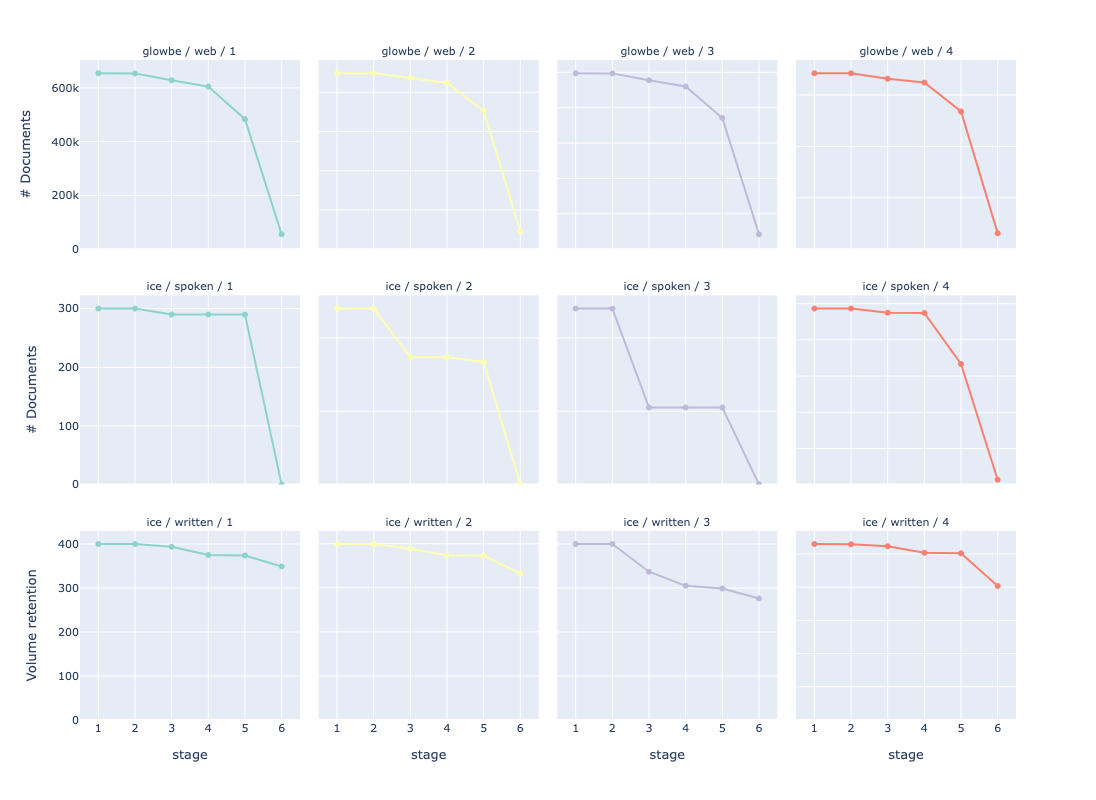

In [197]:
render_volume_line("by_source_genre_cluster_english")

In [ ]:
# !mkdir -p ../output/eval/images/retention/volume/logscale

In [ ]:
# for key in series:
    # render_volume_line(key).show()
    # render_volume_line(key).write_image(f"../output/eval/images/retention/volume/logscale/{key}.png")

In [ ]:
# series["by_mobility"]
pmi_data["by_mobility"]

# (WIP) Retention Rate (RR) and Log-Retention Penalty (LRP)
*Operationalized hypothesis*: Cluster 1 will have the highest retention rate at each stage of the pipeline. 

The results are basically **negative**: all clusters except for code-switching share nearly identical relative retention rates. This is mostly due to the volume of GloWbe data obscuring the effects *within* clusters. See results for `by_cluster_in_ice` compared to `by_cluster_in_glowbe`, or `by_genre_in_cluster_*`.

Also note that the retention rate for LinCE at stage 5 of the pipeline is highly inflated but only accounts for 48 out of 68 input documents (from a set of originally 172K documents).

## Line Charts

In [ ]:
def render_retention_line(subset_key, color_map=COLOR_MAP,height=800,width=400, font_size=11):
    df = series[subset_key]
    fig = px.line(
        df, x="stage", y="retention", 
        line_group="value", facet_row="color_key",
        # color_discrete_map=color_map, markers=True,
        title=f"Retention by stage: {subset_key}",
        # category_orders={"color_key": ["1", "2", "3", "4"]}
    )
    fig.update_layout(width=width, height=height, font=dict(size=font_size))
    fig.update_yaxes(range=[0,1.1], tickformat=".1%")
    fig.update_xaxes(range=[-0.1,6.1], dtick=1)
    fig.for_each_annotation(lambda a: a.update(text=f"Cluster {a.text.split("=")[-1]}"))
    # fig.update_traces(opacity=0.5) 
    return fig

In [ ]:
series["by_component_genre"]

In [ ]:
# !mkdir -p ../output/eval/images/retention/relative

In [ ]:
# for key in series:
#     render_retention_line(key).write_image(f"../output/eval/images/retention/relative/{key}.png")
    # render_retention_line(key).show()

In [ ]:
subset = "by_source_genre"

# render_sankey(subset).show()
render_retention_line(subset).show()
# render_volume_line(subset).show()
# series["by_component_spoken"]

In [ ]:
def compute_relative_rate(subset_key, base_key):
    data = series[subset_key]
    base_data = data.loc[data.value == base_key]
    base_rate = base_data.loc[base_data.stage == 5, "cumulative_lrp"].values[0]

    new_data = {
        subset_key: [],
        "relative_rate": [],
        "delta_to_base": []
    }
    for val, df in series[subset_key].groupby("value"):
        # print(val)
        subset_rate = df.loc[df.stage == 5, "cumulative_lrp"].values[0]
    
        lrp_diff = subset_rate - base_rate
        result = math.exp(lrp_diff)
        # print("LRP: ", lrp_diff)
        # print(f"Relative to {base_key}: ", result)
        new_data[subset_key].append(val)
        new_data["relative_rate"].append(result)
        new_data["delta_to_base"].append(result - 1)
    new_df = pd.DataFrame(new_data)
    new_df = new_df.round(4)
    return new_df

rr_cluster = compute_relative_rate("by_cluster", "1")
# rr_component = compute_relative_rate("by_component", "us")
rr_mobility = compute_relative_rate("by_mobility", "high")

In [ ]:
# rr_component_written = compute_relative_rate("by_component_written", "us")
# rr_component_written
# print(rr_genre.to_latex())
rr_mobility

In [ ]:
rr_component_genre = compute_relative_rate("by_component_genre", "us / W2B")
rr_component_genre

## Filter Contributions (Waterfall Chart)
*Operationalized hypothesis*: LangID will be associated with the highest contributions to data distortion (measured by LRP).

The results are **negative**. For these data sources, the FineWeb Quality filter contributes the most to data distortion overall.

In [ ]:
def render_algo_lrp_contribution(subset_key, color_map=COLOR_MAP, width=800, height=800, font_size=11):
    df = series[subset_key]
    fig = go.Figure(go.Waterfall(
        orientation="v",
        x=df.stage_name,
        y=df.lrp,
    ))
    fig.update_yaxes(dtick=0.1, range=[-0.1,1.1])
    fig.update_layout(width=width, height=height, font=dict(size=font_size))
    return fig

render_algo_lrp_contribution("overall", height=800)
# render_lrp_contribution("overall", height=500).write_image(f"../output/eval/images/retention/lrp_by_stage.png")

## Stacked Bar Chart (ABANDONED)

*Operationalized hypothesis:* Cluster 1 will be the least distorted by filters, measured by the lowest cumulative LRP.

The results are **negative** - Cluster 1's LRP is more or less 

In [80]:
def render_lrp_stack(subset_key, sort_key="color_key", font_size=18):
    df = series[subset_key].sort_values(by=sort_key)
    fig = px.bar(
        df, x="value", y="retention", color="stage_name",
        facet_row="color_key",
        labels={"lrp": "Log Rejection Penalty", "value": "Dialect Typology"}
    )
    fig.update_xaxes(matches=None)
    fig.update_yaxes(title_text="")
    fig.update_layout(
        width=800, height=800,
        font=dict(size=font_size), 
        legend=dict(
            title="Algorithmic Filter",
            # maxheight=0.1
            yanchor="middle",
            y=0.5
        )
    )
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
    return fig

In [79]:
# for key in series:
#     render_lrp_contribution(key).write_image(f"../output/eval/images/retention/contribution/{key}.png")
# !mkdir -p ../output/eval/images/lrp
# render_lrp_stack("by_cluster", "value").write_image(f"../output/eval/images/lrp/typology_cluster.png")
df = series["by_source_genre_cluster_english"]
df.loc[df.color_key=="1"]

,value,stage,stage_name,included,total,retention,lrp,cumulative_lrp,value_parts,color_key
0,glowbe / web / 1,1,📖 - READER: 🐿 Jsonl,654544,654544,1.000000,-0.000000,0.000000,"[glowbe, web, 1]",1
12,glowbe / web / 1,2,🔻 - FILTER: 🌍 Language ID,653929,654544,0.999060,0.000940,0.000940,"[glowbe, web, 1]",1
24,glowbe / web / 1,3,🔻 - FILTER: 👯 Gopher Repetition,628320,653929,0.960838,0.039949,0.040889,"[glowbe, web, 1]",1
36,glowbe / web / 1,4,🔻 - FILTER: 🥇 Gopher Quality,604832,628320,0.962618,0.038099,0.078988,"[glowbe, web, 1]",1
48,glowbe / web / 1,5,🔻 - FILTER: ⛰ C4 Quality,483748,604832,0.799806,0.223387,0.302375,"[glowbe, web, 1]",1
60,glowbe / web / 1,6,🔻 - FILTER: 🍷 FineWeb Quality,55169,483748,0.114045,2.171163,2.473538,"[glowbe, web, 1]",1
4,ice / spoken / 1,1,📖 - READER: 🐿 Jsonl,300,300,1.000000,-0.000000,0.000000,"[ice, spoken, 1]",1
16,ice / spoken / 1,2,🔻 - FILTER: 🌍 Language ID,300,300,1.000000,-0.000000,0.000000,"[ice, spoken, 1]",1
28,ice / spoken / 1,3,🔻 - FILTER: 👯 Gopher Repetition,290,300,0.966667,0.033902,0.033902,"[ice, spoken, 1]",1
40,ice / spoken / 1,4,🔻 - FILTER: 🥇 Gopher Quality,290,290,1.000000,-0.000000,0.033902,"[ice, spoken, 1]",1


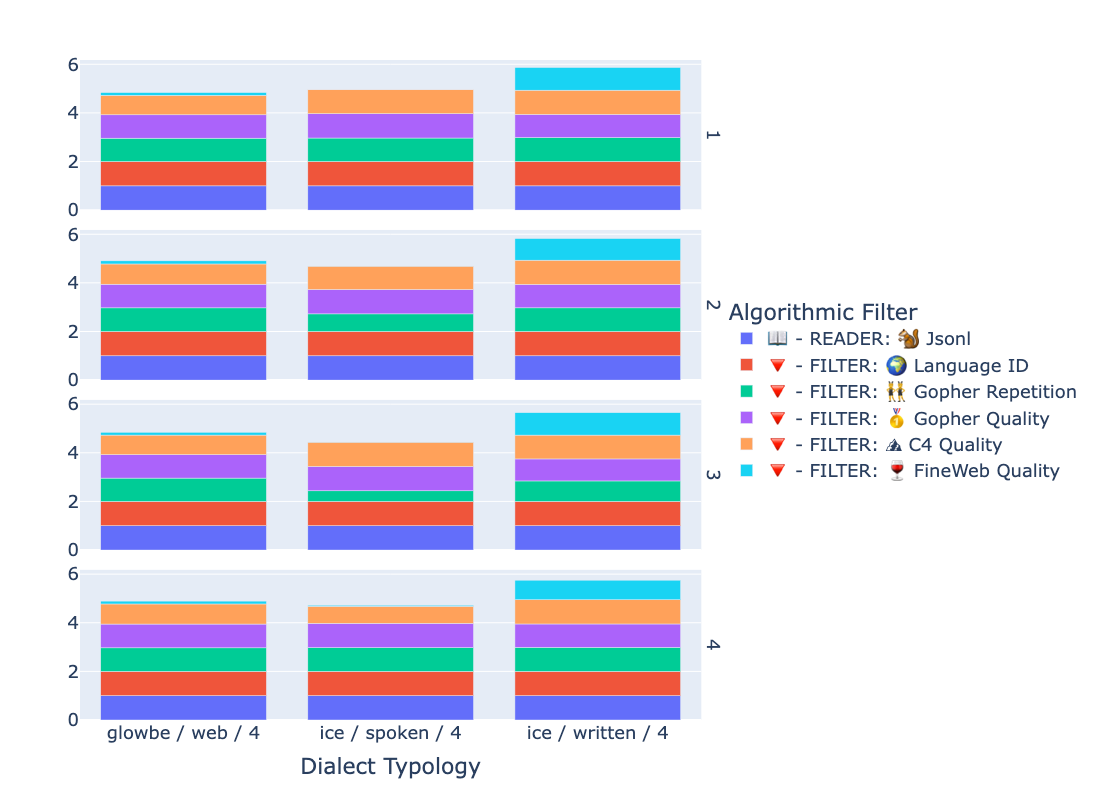

In [81]:
# series["by_cluster"]
render_lrp_stack("by_source_genre_cluster_english", "value")

## Render Sankey diagrams (ABANDONED)

In [ ]:
def render_sankey(subset_key, color_map=COLOR_MAP, width=1200, height=600, font_size=11):
    sd = sankeys[subset_key]
    node_colors = [
        EXCLUDED_COLOR if label == "" else color_map.get(value, "#999999")
        for label, value in zip(sd["node"]["label"], sd["node"]["customdata"])
    ]
    
    fig = go.Figure(go.Sankey(
        arrangement="fixed",
        node={**sd["node"], "color": node_colors},
        link=sd["link"]
    ))
    
    fig.update_layout(title=subset_key, width=width, height=height, font=dict(size=font_size))
    return fig

In [ ]:
render_sankey("by_cluster")